In [3]:
import pandas as pd

In [4]:
def rename_columns(df, old_cols, new_cols):
    """
    Rename a series of columns using two aligned lists.
    """
    if len(old_cols) != len(new_cols):
        raise ValueError("old_cols and new_cols must have the same length")

    return df.rename(columns=dict(zip(old_cols, new_cols)))

In [82]:
# if args.type == 'txfr':

        ### transmission asset

file_loc = r"TXFR-T_REPLACEMENT LIST_01_12_26.xlsm"
df = pd.read_excel(file_loc, sheet_name = "Mar 2026 Repl Ranking by Phase", index_col=None, na_values=['NA'], skiprows=0)

sel_cols = ['SAP Equipment ID', 'Sub Name', 'Highest Cumulative POF ',
            'Reliability Risk Matrix (PoF,CoF)']

df_t_txfr = df[sel_cols]

df_t_txfr=rename_columns(df_t_txfr, ['SAP Equipment ID', 'Sub Name', 'Highest Cumulative POF '], 
                                ['Equipment', 'Substation Name', 'POF'])

df_t_txfr['line'] = 'T'

    ### distribution asset

file_loc = r"D_Transf_Risk_Ranking_Under_Const 2026.xlsx"
df = pd.read_excel(file_loc, sheet_name = "Distribution Transformers", index_col=None, na_values=['NA'], skiprows=0, engine='openpyxl')

sel_cols = ['SAP Equipment I.D.', 'Substation Name', 'Highest POF ','Reliability Risk Matrix (PoF,CoF)']

df_d_txfr = df[sel_cols]

df_d_txfr=rename_columns(df_d_txfr, ['SAP Equipment I.D.', 'Highest POF '], 
                        ['Equipment', 'POF'])

df_d_txfr['line'] = 'D'
# if args.line ==1:
asset_files = pd.concat([df_d_txfr, df_t_txfr])
# elif args.line ==2:
#     asset_files = df_t_txfr
# elif args.line == 3:
#     asset_files = df_d_txfr
# else:
#     raise ValueError('The line of the asset is not correctly selected. Choose between 1,2,3 (T&D, T, D, respectively).')
# asset_files['type'] = 'TXFR'

In [88]:
new_df = pd.read_csv(r"C:\Users\SIH5\OneDrive - PGE\Desktop\results_2026-08-03T21_08_50.923Z.csv")

In [29]:
len(asset_files[asset_files['line']=='T'])

456

In [89]:
new_df = new_df[new_df['system_status'].isin(['[INST]', '[INAC, INST]'])]
new_df = new_df[new_df['planner_group'].isin(['TS1', 'DS1'])]

In [56]:
new_df[new_df['sap_equipment_id'].isin([41158251,
41158253,
41158254,
44918680,
45247388,
45274594])]['planner_group']

2950    DS1
2952    DS1
2953    DS1
3981    DS1
4115    DS1
4123    DS1
Name: planner_group, dtype: object

In [99]:
import numpy as np

In [104]:
pd.merge(asset_files, new_df, left_on='Equipment', right_on='sap_equipment_id', how='left')[pd.merge(asset_files, new_df, left_on='Equipment', right_on='sap_equipment_id', how='left')[
    'sap_equipment_id'].isna()]#['system_status'].unique() #, 'planner_group'

,Equipment,Substation Name,POF,"Reliability Risk Matrix (PoF,CoF)",line,substation_transformer_id,sap_equipment_id,user_status,substation_id,substation_name,...,nlt_a_1_pri_rated_voltage_v,nlt_b_2_pri_rated_voltage_v,nlt_c_3_pri_rated_voltage_v,nlt_d_4_pri_rated_voltage_v,nlt_e_5_pri_rated_voltage_v,nlt_a_1_sec_rated_voltage_v,nlt_b_2_sec_rated_voltage_v,nlt_c_3_sec_rated_voltage_v,nlt_d_4_sec_rated_voltage_v,nlt_e_5_sec_rated_voltage_v
510,41012511,ARBUCKLE,0.400068,42,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
599,41014124,ARBUCKLE,0.070000,22,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
600,41014066,ARBUCKLE,0.070000,22,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
601,41014093,ARBUCKLE,0.070000,22,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1923,42735572,ARCO SUB,0.014276,14,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1924,43144204,ARCO SUB,0.020000,14,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1925,42553779,BRIDGEVILLE SUB,0.070982,24,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1926,42734697,BUTTE SUB,0.050000,24,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1927,41184033,CHRISTIE SUB,0.014208,14,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1928,40989612,COBURN SUB,0.025000,14,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
filter = '('
for i in range(len(df_t_txfr)):
    if i != len(df_t_txfr):
        filter += f"'{str(df_t_txfr.iloc[i, 0])}',"
    else:
        filter += f"'{str(df_t_txfr.iloc[i, 0])}')"

In [22]:
len(df_t_txfr)

456

In [18]:
print(filter)

('42735572','43144204','42553779','42734697','41184033','40989612','42686386','42686875','40989631','42692025','40989656','42626324','44611881','40989714','42695718','40989681','42710844','40989524','40989800','42735593','42735586','43144171','42735592','43144172','42735589','43144170','41014631','41014619','41012527','42704633','42704631','41015282','41014946','41014947','42707082','42630400','41234815','41210005','42753803','42753756','42753802','42753804','42641306','41209640','45488239','44145401','41305331','41305330','41304932','41012681','41012053','41012054','45278026','42693062','42693051','42693059','42693054','44414360','41012778','41012780','41014672','41012775','41012777','41012776','41358360','41358358','41358359','41335023','42717692','42717682','42717638','42717686','41015172','41015169','41015171','41368659','41368660','41368661','41368658','42748559','44726981','42833270','42833268','42833267','42833269','43195560','41012836','41015250','41015249','41339637','41202294

In [19]:
filter_d = '('
for i in range(len(df_d_txfr)):
    if i != len(df_d_txfr):
        filter_d += f"'{str(df_d_txfr.iloc[i, 0])}',"
    else:
        filter_d += f"'{str(df_d_txfr.iloc[i, 0])}')"

In [20]:
print(filter_d)

('41013832','41015294','41160708','41160706','41160707','41013883','41013802','41014459','41015314','41014279','41014280','41014789','41014471','41138818','41138819','41014196','41014221','41014235','41014953','41013430','41013431','41013429','41013095','41012235','41013096','41012234','41015087','41011899','41013827','41012313','41013185','41013184','41013183','41011900','41014067','41012450','41014617','41012449','41012451','41012583','41012585','41012582','41014145','41014149','41014150','41014146','41014396','41014151','41015088','41013689','41015048','41012081','41011985','41012034','41158253','41158254','41158251','41014218','41013826','41013662','41013658','41013665','41013784','41014668','41013761','41014595','41014201','41014665','41014955','41012664','41012663','41014954','41012662','41012869','41014183','41014781','41012061','41012060','41013828','41013829','41013831','41013747','41013804','41013473','41013472','41013474','41012473','41013274','41013272','41013275','41012730

In [21]:
1106 + 817

1923

In [83]:
asset_files = asset_files[~((asset_files['Equipment'].isin([41158251,
41158253,
41158254,
44918680,
45247388,
45274594])) & (asset_files['line']=='T'))]

In [74]:
asset_files = asset_files.drop(index=[149, 150, 151, 323, 324, 325]).reset_index()

In [84]:
asset_files.groupby('Equipment').count()[asset_files.groupby('Equipment').count()['Substation Name']==2]

,Substation Name,POF,"Reliability Risk Matrix (PoF,CoF)",line
Equipment,,,,


In [87]:
len(asset_files)

2373

In [81]:
len(asset_files)

2367

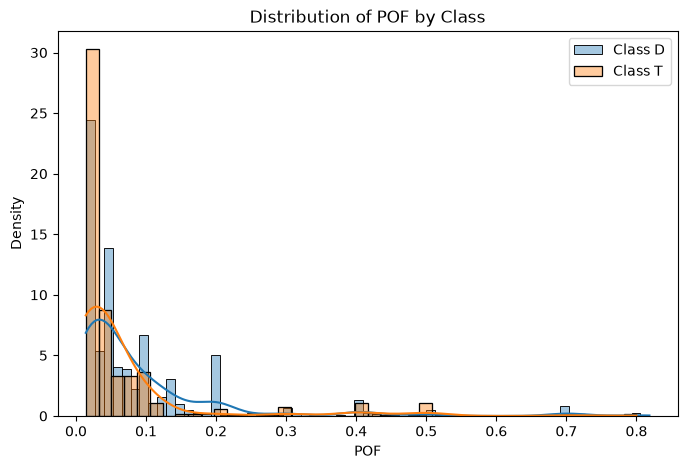

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

class_col = "line"      # column defining the classes
feature = "POF"      # feature to visualize

plt.figure(figsize=(8, 5))

for cls in asset_files[class_col].unique():
    sns.histplot(
        data=asset_files[asset_files[class_col] == cls],
        x=feature,
        kde=True,
        stat="density",
        label=f"Class {cls}",
        alpha=0.4
    )

plt.legend()
plt.title(f"Distribution of {feature} by Class")
plt.show()


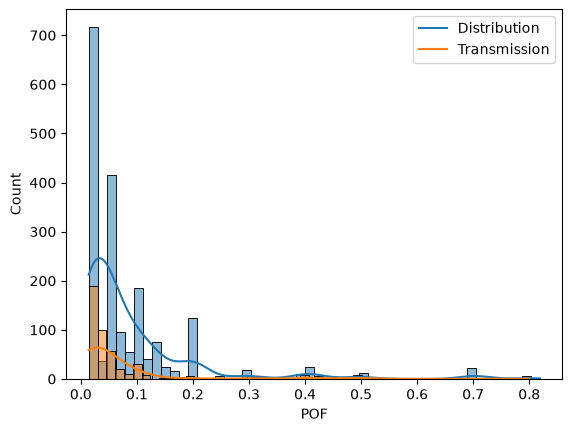

In [91]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=asset_files[asset_files['line']=='D'], x='POF', bins=50, kde=True)
sns.histplot(data=asset_files[asset_files['line']=='T'], x='POF', bins=50, kde=True)
plt.legend(['Distribution', 'Transmission'])
plt.show()

In [97]:
asset_files[asset_files['line']=='T'].POF.sum()

np.float64(30.03940334571026)

In [105]:
### transmission asset
file_loc = r"T_BRKR 1-N Under Const (1 15 2026).xlsx"
df = pd.read_excel(file_loc, sheet_name = "Transmission Breakers", index_col=None, na_values=['NA'], skiprows=0)

sel_cols = [' Equipment', 'Substation Name', 'Highest PoF',
            'Reliability Risk Matrix (PoF,CoF)']

df_t_brkr = df[sel_cols]


df_t_brkr=rename_columns(df_t_brkr, [' Equipment', 'Highest PoF'], 
                        ['Equipment', 'POF'])

df_t_brkr['line'] = 'T'
### distribution asset
file_loc = r"D BRKR 1-N Under Const 2026.xlsx"
df = pd.read_excel(file_loc, sheet_name = "Distribution Breakers", index_col=None, na_values=['NA'], skiprows=0, engine='openpyxl')

sel_cols = ['Equipment', 'Substation Name', 'Highest Cummulative PoF',
            'Reliability Risk Matrix (PoF,CoF)']

df_d_brkr = df[sel_cols]

df_d_brkr=rename_columns(df_d_brkr, ['Highest Cummulative PoF'], 
                        ['POF'])


df_d_brkr['line'] = 'D'


asset_files = pd.concat([df_d_brkr, df_t_brkr])

In [121]:
len(asset_files)

6747

In [114]:
asset_files[asset_files['Equipment']==40991421]

,Equipment,Substation Name,POF,"Reliability Risk Matrix (PoF,CoF)",line
2975,40991421,SAN FRAN P(HUNTERS POINT) SUB,0.179729,33,D
660,40991421,NaN,0.186580,33,T


In [118]:
asset_files = asset_files[~((asset_files['Equipment'].isin([40991421])) & (asset_files['line']=='T'))]

In [113]:
asset_files.groupby('Equipment').count()[asset_files.groupby('Equipment').count()['line']==2]

,Substation Name,POF,"Reliability Risk Matrix (PoF,CoF)",line
Equipment,,,,
40991421,1,2,2,2


In [115]:
df_f_brkr = pd.read_csv(r"C:\Users\SIH5\Downloads\circuitbreaker_v2_augmented.csv")

C:\Users\SIH5\AppData\Local\Temp\ipykernel_21568\604236715.py:1: DtypeWarning: Columns (4,49,57,60,72,79,80,92,117,122,139,144,163,164,167,168,188,189,204,212,213,222,232,233,248,249,256,257) have mixed types. Specify dtype option on import or set low_memory=False.
  df_f_brkr = pd.read_csv(r"C:\Users\SIH5\Downloads\circuitbreaker_v2_augmented.csv")


In [117]:
df_f_brkr[df_f_brkr['sap_equipment_id']==40991421].planner_group

7995    DS1
Name: planner_group, dtype: object

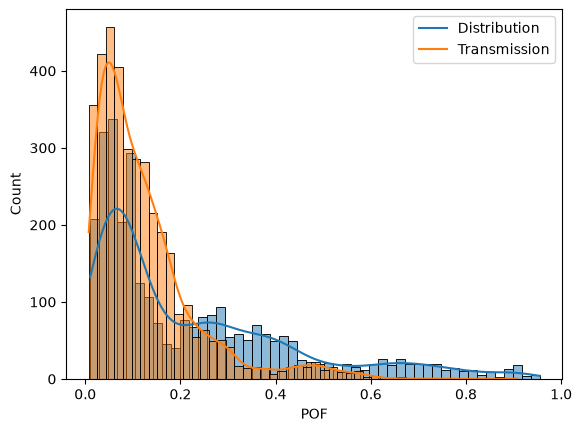

In [122]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=asset_files[asset_files['line']=='D'], x='POF', bins=50, kde=True)
sns.histplot(data=asset_files[asset_files['line']=='T'], x='POF', bins=50, kde=True)
plt.legend(['Distribution', 'Transmission'])
plt.show()

In [ ]:
asset_files[asset_files['line']=='D'].POF.describe()

count    3014.000000
mean        0.222518
std         0.213414
min         0.010400
25%         0.060326
50%         0.126406
75%         0.328613
max         0.954712
Name: POF, dtype: float64

In [132]:
len(df_f_brkr)

18953

In [ ]:
[pd.merge(asset_files, df_f_brkr, left_on='Equipment', right_on='sap_equipment_id', how='inner')['system_status']=='']#['system_status'].unique()

In [147]:
pd.merge(asset_files, df_f_brkr, left_on='Equipment', right_on='sap_equipment_id', how='left')[
    pd.merge(asset_files, df_f_brkr, left_on='Equipment', right_on='sap_equipment_id', how='left')['sap_equipment_id'].isna()
]

,Equipment,Substation Name,POF,"Reliability Risk Matrix (PoF,CoF)",line,ed_circuitbreaker_id,asset_kind,gis_globalid,sap_equipment_id,position,...,reclose_blocking_idc_code,reclosing_capability_idc,reclosing_capability_idc_code,scada_idc,scada_idc_code,status,status_code,control_ser_num,epss_device,region
330,40995300,STELLING SUB,0.602107,43,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
480,40995565,BULLARD SUB,0.385208,42,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
551,40992191,CAMP EVERS SUB,0.756000,53,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
846,40992500,GIFFEN SUB,0.315695,42,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1940,40990870,KERN OIL SUB,0.253795,43,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6324,44706773,"ORO LOMA SUB, CIRCUIT BREAKERS",0.027724,14,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6471,45040548,"FMC SUB, CIRCUIT BREAKERS",0.022937,14,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [145]:
df_f_brkr[(df_f_brkr['planner_group'].isin(['DS1', 'TS1'])) & (df_f_brkr['system_status'].isin(['[INST]', '[INAC, INST]']))][
    df_f_brkr[(df_f_brkr['planner_group'].isin(['DS1', 'TS1'])) & (df_f_brkr['system_status'].isin(['[INST]', '[INAC, INST]']))]['planner_group']=='DS1'
]

,ed_circuitbreaker_id,asset_kind,gis_globalid,sap_equipment_id,position,equipment_description,substation_feeder_id,substation_functional_location,city,city_curation_notes,...,reclose_blocking_idc_code,reclosing_capability_idc,reclosing_capability_idc_code,scada_idc,scada_idc_code,status,status_code,control_ser_num,epss_device,region
0,40997243-{82F52100-EF6A-4495-9E78-3704DCB379DD},substationCircuitbreaker,{82F52100-EF6A-4495-9E78-3704DCB379DD},40997243.0,1101,1101 DIST. OIL BREAKER 3 TANK,1311BK1,ETS.09.12959,SAN LEANDRO,mismatched citys; SAP chosen,...,NaN,NaN,NaN,Yes,Y,In Service,5.0,NaN,NaN,North Valley & Sierra
4,40993723-{3B19E3F6-C66B-4694-9381-0B80F3B7C764},substationCircuitbreaker,{3B19E3F6-C66B-4694-9381-0B80F3B7C764},40993723.0,1110,1110 DISTRIBUTION VACUUM BREAKER,10297BK3,ETS.19.13082,CHICO,mismatched citys; SAP chosen,...,NaN,NaN,NaN,Yes,Y,In Service,5.0,MAHC14000054,No,North Valley & Sierra
10,40992148-NA,substationCircuitbreaker,NaN,40992148.0,NaN,1101 DISTRIBUTION VACUUM BREAKER,NaN,ETS.02.12184,ROUND MOUNTAIN,GIS missing city,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,42568443-NA,substationCircuitbreaker,NaN,42568443.0,NaN,BK 1 DISTRIBUTION VACUUM BREAKER,NaN,ETS.12.12948,SAN FRANCISCO,GIS missing city,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,45511269-NA,substationCircuitbreaker,NaN,45511269.0,1200,1200 DISTRIBUTION VACUUM BREAKER,NaN,ETS.06.10097,EUREKA,GIS missing city,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18945,45587983-{E247EBBF-8B5D-49E6-B3DE-54825EF4E09C},substationCircuitbreaker,{E247EBBF-8B5D-49E6-B3DE-54825EF4E09C},45587983.0,1102.0,1102 DISTRIBUTION VACUUM BREAKER,15206BK1,ETS.04.13606,ROCKLIN,mismatched citys; SAP chosen,...,NaN,NaN,NaN,Yes,Y,In Service,5.0,AAHC13002474,NaN,North Valley & Sierra
18946,40992184-{E4917E6F-1BA6-4862-A8C9-4C8A7009E9E7},substationCircuitbreaker,{E4917E6F-1BA6-4862-A8C9-4C8A7009E9E7},40992184.0,1101.0,1101 DISTRIBUTION VACUUM BREAKER,4282BK1,ETS.13.12218,CLOVERDALE,mismatched citys; SAP chosen,...,NaN,NaN,NaN,Yes,Y,In Service,5.0,AAHC16001371,Yes,North Coast
18948,40993063-{3CA2D923-0637-4424-B939-A09B0DEC4FEC},substationCircuitbreaker,{3CA2D923-0637-4424-B939-A09B0DEC4FEC},40993063.0,1109.0,1109 DISTRIBUTION VACUUM BREAKER,1376BK1,ETS.09.12736,HAYWARD,mismatched citys; SAP chosen,...,NaN,NaN,NaN,Yes,Y,In Service,5.0,NaN,NaN,North Valley & Sierra
18951,40990180-{F878E505-B299-489C-AAE0-26906AE947F2},substationCircuitbreaker,{F878E505-B299-489C-AAE0-26906AE947F2},40990180.0,1102.0,1102 DISTRIBUTION VACUUM BREAKER,25361BK2,ETS.14.12045,ATWATER,GIS missing city,...,NaN,NaN,NaN,Yes,Y,In Service,5.0,NONE,NaN,NaN
